In [1]:
import sys
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats


from scipy.stats import mannwhitneyu
from scipy.stats import levene

load prepreocesed biodata activity

In [2]:
df = pd.read_csv("/workspaces/Drug_discovery/data/processed/egfr_bioactivity_cleaned.csv")
df.head()


,molecule_chembl_id,canonical_smiles,inchi_key,pchembl_value,bioactivity_class,group_type
0,CHEMBL268868,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,6.520,active,single_entry
1,CHEMBL2029442,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(c1cccc(N)...,AAFHSECTTHOVFV-UHFFFAOYSA-N,6.320,active,single_entry
2,CHEMBL2048906,CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl...,AAGKMGNYUYCEPD-UHFFFAOYSA-N,8.540,active,single_entry
3,CHEMBL5757238,C=CC(=O)Nc1cc(Nc2nccc(-c3cnc4c(ccn4C)c3)n2)c(O...,AAGOVSWSOCZTHE-UHFFFAOYSA-N,8.505,active,nonzero_sd
4,CHEMBL1240554,CCOc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1OC,AAHKGRWRYBCWDL-UHFFFAOYSA-N,5.850,intermediate,single_entry


# Calculate lipinske descritors

Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.

The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton

Octanol-water partition coefficient (LogP) < 5

Hydrogen bond donors < 5

Hydrogen bond acceptors < 10

In [3]:
df.canonical_smiles

0               O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21
1       COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(c1cccc(N)...
2       CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl...
3       C=CC(=O)Nc1cc(Nc2nccc(-c3cnc4c(ccn4C)c3)n2)c(O...
4               CCOc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1OC
                              ...                        
9871    NC1CCN(Cc2ccn3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c...
9872    CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C)c4n3)cc2)CC1
9873    C=CC(=O)Nc1cc(Nc2nccc(NC(=O)c3cccc4ccccc34)n2)...
9874    C=CC(=O)Nc1cccc(Nc2ncc3ncc(=O)n(-c4ccc(OC)cc4)...
9875    Cc1nc(C)c(/C=C2\CC(C)C/C(=C\c3nc(C)c(C)nc3C)C2...
Name: canonical_smiles, Length: 9876, dtype: object

In [4]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation
def lipinski(smiles, verbose=False):

  mol_data = []
  for elem in smiles:
    mol = Chem.MolFromSmiles(elem)
    mol_data.append(mol)

  baseData = np.arange(1,1)
  i=0
  for mol in mol_data:

    desc_MolWt = Descriptors.MolWt(mol)
    desc_MolLogP = Descriptors.MolLogP(mol)
    desc_NumHDonors = Lipinski.NumHDonors(mol)
    desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
    desc_TPSA  = Descriptors.TPSA(mol)
    desc_NumRotatableBonds = Descriptors.NumRotatableBonds(mol)


    row = np.array([desc_MolWt,
                    desc_MolLogP,
                    desc_NumHDonors,
                    desc_NumHAcceptors,
                    desc_TPSA,
                    desc_NumRotatableBonds])

    if(i==0):
      baseData = row
    else:
      baseData = np.vstack([baseData, row])
    i = i+1
    
  columnNames = ["MW", "LogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds"]
  descriptors = pd.DataFrame(data=baseData, columns=columnNames)

  return descriptors

In [5]:
df_lipinski = lipinski(df.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds
0,329.359,4.05740,3.0,4.0,70.23,4.0
1,474.569,3.26630,2.0,8.0,103.09,5.0
2,478.965,5.36640,2.0,8.0,93.96,7.0
3,500.607,3.90480,2.0,9.0,100.44,10.0
4,353.426,3.59790,1.0,7.0,88.08,5.0
...,...,...,...,...,...,...
9871,480.975,4.76750,2.0,7.0,80.71,7.0
9872,414.517,3.60230,2.0,8.0,74.14,5.0
9873,537.624,4.51060,3.0,8.0,111.72,8.0
9874,414.425,3.05240,2.0,8.0,111.03,6.0


#Combine dataframes

In [6]:
df_combined = pd.concat([df, df_lipinski], axis=1)

In [7]:
df_combined.head()

,molecule_chembl_id,canonical_smiles,inchi_key,pchembl_value,bioactivity_class,group_type,MW,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds
0,CHEMBL268868,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,6.520,active,single_entry,329.359,4.0574,3.0,4.0,70.23,4.0
1,CHEMBL2029442,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(c1cccc(N)...,AAFHSECTTHOVFV-UHFFFAOYSA-N,6.320,active,single_entry,474.569,3.2663,2.0,8.0,103.09,5.0
2,CHEMBL2048906,CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl...,AAGKMGNYUYCEPD-UHFFFAOYSA-N,8.540,active,single_entry,478.965,5.3664,2.0,8.0,93.96,7.0
3,CHEMBL5757238,C=CC(=O)Nc1cc(Nc2nccc(-c3cnc4c(ccn4C)c3)n2)c(O...,AAGOVSWSOCZTHE-UHFFFAOYSA-N,8.505,active,nonzero_sd,500.607,3.9048,2.0,9.0,100.44,10.0
4,CHEMBL1240554,CCOc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1OC,AAHKGRWRYBCWDL-UHFFFAOYSA-N,5.850,intermediate,single_entry,353.426,3.5979,1.0,7.0,88.08,5.0


In [8]:
# Definir los umbrales de violación (True = viola)
df_combined['violates_mw'] = df_combined['MW'] > 500
df_combined['violates_logp'] = df_combined['LogP'] > 5
df_combined['violates_hdonors'] = df_combined['NumHDonors'] > 5
df_combined['violates_hacceptors'] = df_combined['NumHAcceptors'] > 10

# Contar cuántas reglas viola (suma de booleanos)
violation_cols = ['violates_mw', 'violates_logp', 'violates_hdonors', 'violates_hacceptors']
df_combined['ro5_violations'] = df_combined[violation_cols].sum(axis=1)

# Ver la distribución
print(df_combined['ro5_violations'].value_counts().sort_index())

ro5_violations
0    4381
1    2666
2    2612
3     210
4       7
Name: count, dtype: int64


In [9]:
# Calcular porcentajes
viol_counts = df_combined['ro5_violations'].value_counts().sort_index()
percentages = (viol_counts / len(df_combined)) * 100

# Crear un DataFrame con conteo y porcentaje
result = pd.DataFrame({
    'ro5_violations': viol_counts.index,
    'count': viol_counts.values,
    'percentage (%)': percentages.values.round(2)
})

# Mostrar con formato
print(result.to_string(index=False))

 ro5_violations  count  percentage (%)
              0   4381           44.36
              1   2666           26.99
              2   2612           26.45
              3    210            2.13
              4      7            0.07


#Convert IC50 to pIC50

To allow IC50 data to be more uniformly distributed, we will convert IC50 to the negative logarithmic scale which is essentially -log10(IC50).

This custom function pIC50() will accept a DataFrame as input and will:

Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10
Take the molar value and apply -log10
Delete the standard_value column and create a new pIC50 column

el cambio se relaiza por que IC50 tiene una distribucion menos normal

In [10]:
df_combined.pchembl_value.describe()

count    9876.000000
mean        6.947821
std         1.287382
min         4.000000
25%         6.000000
50%         7.020000
75%         7.953725
max        11.000000
Name: pchembl_value, dtype: float64

In [11]:
df_combined.to_csv('/workspaces/Drug_discovery/data/processed/egfr_bioactivity_3class.csv', index=False)

In [12]:
# ── Binary dataset (active + inactive only, no intermediate) ──────────────────
df_2class = df_combined[df_combined['bioactivity_class'] != 'intermediate'].copy()

df_2class.to_csv('/workspaces/Drug_discovery/data/processed/egfr_bioactivity_2class.csv',  index=False)
print(f'Saved egfr_bioactivity_2class.csv   → {len(df_2class):,} compounds (active + inactive only)')

Saved egfr_bioactivity_2class.csv   → 8,154 compounds (active + inactive only)


#Exploratory Data Analisys (Chemical Space Analisys)


un tipo en chemical space analissi creo el modelo constelación. donde la parte activa de una molecula se presenta mas grande en referencia a las partes no ctivas

In [13]:
import seaborn as sns
sns.set(style='ticks') # stilo con barras gruesas en las axis
import matplotlib.pyplot as plt

#Frequency plot of the 2 bioactivity classes

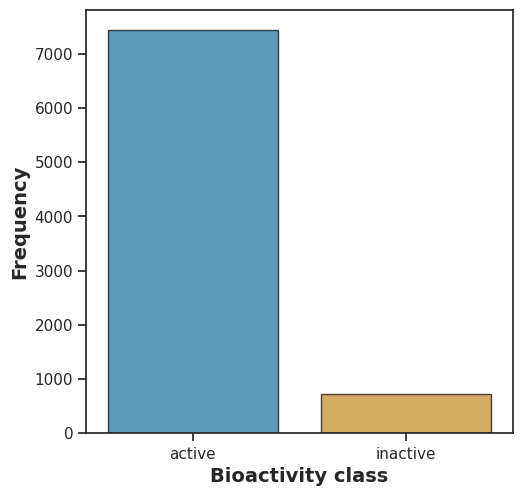

In [14]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(data=df_2class, 
              x='bioactivity_class', 
              hue='bioactivity_class', 
              palette='colorblind', 
              edgecolor='black', 
              alpha=0.7)

plt.xlabel("Bioactivity class", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.savefig("/workspaces/Drug_discovery/figs/plot_bioactivity_class.pdf")
plt.show()

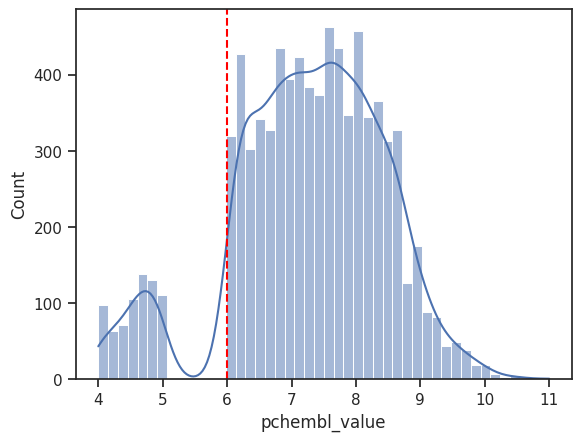

In [34]:
sns.histplot(data=df_2class, x='pchembl_value', kde=True)
plt.axvline(x=6.0, color='red', linestyle='--', label='Active cutoff (pIC50 = 6.0)')

plt.savefig("/workspaces/Drug_discovery/figs/histogram_pchembl_value.pdf")

#Scatter plot MW vs LogP

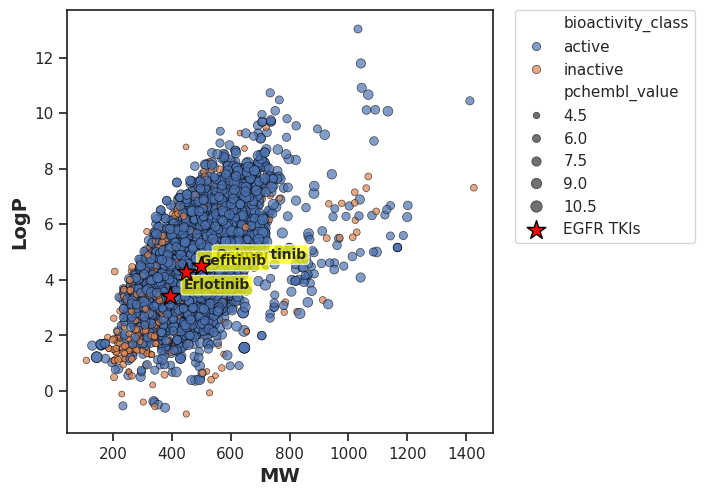

In [16]:
plt.figure(figsize=(5.5, 5.5))

# Tu gráfico original
sns.scatterplot(x=df_2class.MW, y=df_2class.LogP, 
                hue=df_2class.bioactivity_class, 
                size=df_2class.pchembl_value, 
                edgecolor="black", alpha=0.7)

# --- Añadir los tres puntos manuales ---
tki_data = {
    'nombre': ['Osimertinib', 'Erlotinib', 'Gefitinib'],
    'MW': [499.62, 393.44, 446.91],
    'LogP': [4.51, 3.41, 4.28]
}
plt.scatter(tki_data['MW'], tki_data['LogP'], 
            s=200, c='red', marker='*', edgecolors='black', linewidth=1,
            label='EGFR TKIs', zorder=10)

for i in range(len(tki_data['nombre'])):
    plt.annotate(tki_data['nombre'][i], 
                 (tki_data['MW'][i], tki_data['LogP'][i]),
                 xytext=(10, 5), textcoords='offset points',
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7))

# Etiquetas y leyenda
plt.xlabel("MW", fontsize=14, fontweight="bold")
plt.ylabel("LogP", fontsize=14, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.savefig("/workspaces/Drug_discovery/figs/plot_MW_vs_LogP.pdf", bbox_inches='tight')
plt.show()

#BOX PLOTS

#pIC50

stadistical analisys | Mann-whitney U test

pa ver la diferencia es significativa estadisticamente hablando. debido al gran tamaño, se salta el test de normalidad ya que no sule ser el caso. en su lugar se hara QQ plot + visualizaciones

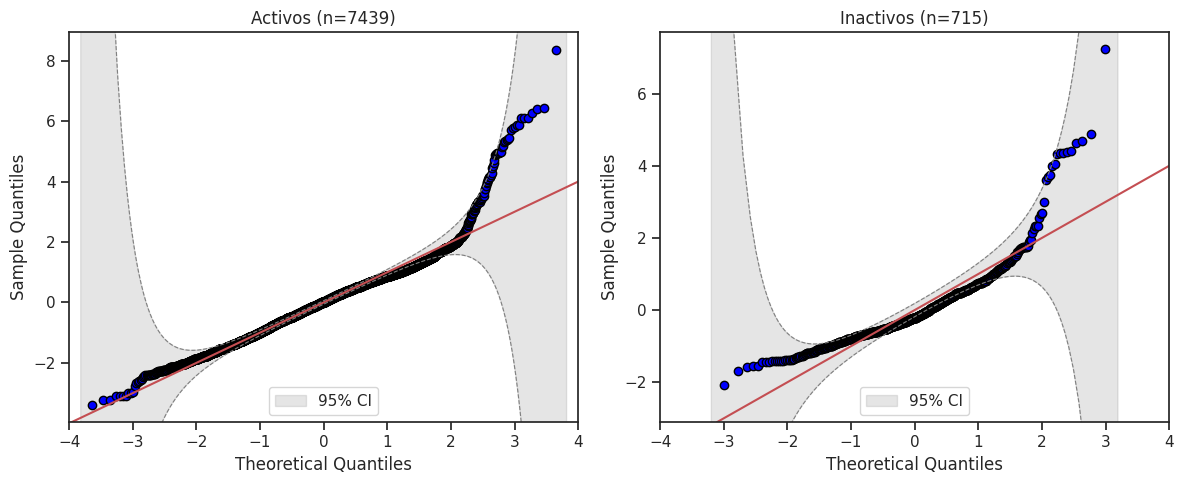

In [19]:
# Tus datos
descriptor = "MW"  # cámbialo si quieres otro descriptor
active = df_2class[df_2class["bioactivity_class"] == "active"][descriptor].dropna()
inactive = df_2class[df_2class["bioactivity_class"] == "inactive"][descriptor].dropna()

def qqplot_with_bands(data, title, ax):
    probplot = sm.ProbPlot(data, dist=stats.norm, fit=True)
    probplot.qqplot(line='45', ax=ax, marker='o', markerfacecolor='blue', 
                    markeredgecolor='black', markersize=6)
    
    n = len(data)
    alpha = 0.05
    z = stats.norm.ppf(1 - alpha/2)
    theoretical_quantiles = stats.norm.ppf((np.arange(1, n+1) - 0.5) / n)
    se = 1 / (np.sqrt(n) * stats.norm.pdf(theoretical_quantiles))
    lower = theoretical_quantiles - z * se
    upper = theoretical_quantiles + z * se
    
    ax.fill_between(theoretical_quantiles, lower, upper, color='gray', alpha=0.2, label='95% CI')
    ax.plot(theoretical_quantiles, lower, '--', color='gray', linewidth=0.8)
    ax.plot(theoretical_quantiles, upper, '--', color='gray', linewidth=0.8)
    ax.set_xlim(-4, 4)  # Limitar el eje X a [-4, 4]
    ax.set_title(title)
    ax.legend()

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
qqplot_with_bands(active, f"Activos (n={len(active)})", ax1)
qqplot_with_bands(inactive, f"Inactivos (n={len(inactive)})", ax2)
plt.tight_layout()
plt.savefig("/workspaces/Drug_discovery/figs/QQ_plot_bioactivity")
plt.show()

In [20]:
# Asegúrate de tener tus datos cargados como listas o arrays de Python.
active = df_2class[df_2class["bioactivity_class"] == "active"]["MW"].dropna()
inactive = df_2class[df_2class["bioactivity_class"] == "inactive"]["MW"].dropna()

# Realiza la prueba de Levene (Brown-Forsythe)
stat, p = levene(active, inactive, center='median')

# Nivel de significancia
alpha = 0.05

print(f"Brown-Forsythe (Levene) Test:")
print(f"Estadístico = {stat:.4f}, p-valor = {p:.4f}")

if p > alpha:
    print("No se rechaza H0: Las varianzas son iguales (homocedasticidad).")
else:
    print("Se rechaza H0: Las varianzas son significativamente diferentes (heterocedasticidad).")

Brown-Forsythe (Levene) Test:
Estadístico = 21.6556, p-valor = 0.0000
Se rechaza H0: Las varianzas son significativamente diferentes (heterocedasticidad).


In [31]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def interpret_effect_size(r):
    r_abs = abs(r)
    if r_abs < 0.1:
        return "negligible"
    elif r_abs < 0.3:
        return "small"
    elif r_abs < 0.5:
        return "moderate"
    else:
        return "large"


def statistical_comparison(descriptor, df, group_col="bioactivity_class",
                      group1="active", group2="inactive",
                      n_bootstrap=1000, random_state=42,
                      verbose=True):

    rng = np.random.default_rng(random_state)

    g1 = df[df[group_col] == group1][descriptor].dropna().values
    g2 = df[df[group_col] == group2][descriptor].dropna().values

    n1, n2 = len(g1), len(g2)
    n_total = n1 + n2

    # Mann–Whitney U
    u_stat, p_value = mannwhitneyu(g1, g2, alternative="two-sided")

    # Rank-biserial effect size. r > 0 → g1 > g2
    r_rb = (2 * u_stat) / (n1 * n2) - 1

    # z-score
    mean_u = n1 * n2 / 2
    std_u = np.sqrt(n1 * n2 * (n_total + 1) / 12)
    z = (u_stat - mean_u) / std_u

    # Median difference
    med_diff = np.median(g1) - np.median(g2)

    # Bootstrap CI
    boot_diffs = []
    for _ in range(n_bootstrap):
        samp1 = rng.choice(g1, size=n1, replace=True)
        samp2 = rng.choice(g2, size=n2, replace=True)
        boot_diffs.append(np.median(samp1) - np.median(samp2))

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    # Overlap
    q1, q3 = np.percentile(g1, [25, 75])
    overlap = np.mean((g2 >= q1) & (g2 <= q3)) * 100

    # -------- INTERPRETATION --------
    effect_label = interpret_effect_size(r_rb)

    if ci_low > 0:
        ci_interpretation = "difference is consistently positive (group1 > group2)"
    elif ci_high < 0:
        ci_interpretation = "difference is consistently negative (group1 < group2)"
    else:
        ci_interpretation = "difference is uncertain (CI includes 0)"

    if med_diff > 0:
        direction = f"{group1} tends to have higher values"
    elif med_diff < 0:
        direction = f"{group2} tends to have higher values"
    else:
        direction = "no clear directional difference"

    if overlap < 25:
        overlap_label = "low overlap (good separation)"
    elif overlap < 50:
        overlap_label = "moderate overlap"
    else:
        overlap_label = "high overlap (poor separation)"

    report = (
        f"{descriptor}: {group1} vs {group2} | "
        f"Effect size r = {r_rb:.3f} ({effect_label}). "
        f"Median difference = {med_diff:.3f} "
        f"(95% CI [{ci_low:.3f}, {ci_high:.3f}] → {ci_interpretation}). "
        f"{direction}. "
        f"Overlap = {overlap:.1f}% ({overlap_label})."
    )

    if verbose:
        print("\n" + report)

    return {
        "descriptor": descriptor,
        "group1": group1,
        "group2": group2,
        "n_group1": n1,
        "n_group2": n2,
        "u_stat": u_stat,
        "p_value": p_value,
        "z_score": z,
        "effect_size_r_rb": r_rb,
        "effect_magnitude": effect_label,
        "median_diff": med_diff,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "ci_interpretation": ci_interpretation,
        "direction": direction,
        "overlap_pct": overlap,
        "overlap_interpretation": overlap_label,
        "report": report
    }

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot_by_class(descriptor, df=df_2class, output_dir="/workspaces/Drug_discovery/figs/", show=True):
    """
    Genera un boxplot y lo muestra en el notebook (si show=True) y lo guarda como PDF.
    """
    plt.figure(figsize=(5.5, 5.5))
    
    sns.boxplot(
        data=df,
        x='bioactivity_class',
        y=descriptor,
        hue='bioactivity_class',
        palette='colorblind',
        legend=False
    )
    
    plt.xlabel("Bioactivity class", fontsize=14, fontweight="bold")
    plt.ylabel(descriptor, fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    # Guardar
    filename = f"{output_dir}plot_{descriptor}.pdf"
    plt.savefig(filename)
    
    # Mostrar en el notebook (sin cerrar la figura)
    if show:
        plt.show()
    else:
        plt.close()  # solo cierra si no se pide mostrar
    
    print(f"Boxplot guardado en: {filename}")

In [32]:
descriptors = ["MW", "LogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds"]

results = []

for desc in descriptors:
    res = statistical_comparison(desc, df_2class)
    results.append(res)

results_df = pd.DataFrame(results)

# Save
results_df.to_csv("/workspaces/Drug_discovery/data/statistics/statistics.csv", index=False)

print(results_df)


MW: active vs inactive | Effect size r = 0.508 (large). Median difference = 127.078 (95% CI [113.868, 135.906] → difference is consistently positive (group1 > group2)). active tends to have higher values. Overlap = 25.9% (moderate overlap).

LogP: active vs inactive | Effect size r = 0.324 (moderate). Median difference = 0.800 (95% CI [0.691, 0.966] → difference is consistently positive (group1 > group2)). active tends to have higher values. Overlap = 35.4% (moderate overlap).

NumHDonors: active vs inactive | Effect size r = 0.201 (small). Median difference = 0.000 (95% CI [0.000, 0.000] → difference is uncertain (CI includes 0)). no clear directional difference. Overlap = 47.3% (moderate overlap).

NumHAcceptors: active vs inactive | Effect size r = 0.468 (moderate). Median difference = 2.000 (95% CI [1.000, 2.000] → difference is consistently positive (group1 > group2)). active tends to have higher values. Overlap = 43.2% (moderate overlap).

TPSA: active vs inactive | Effect size 

---
1. pchembl_value

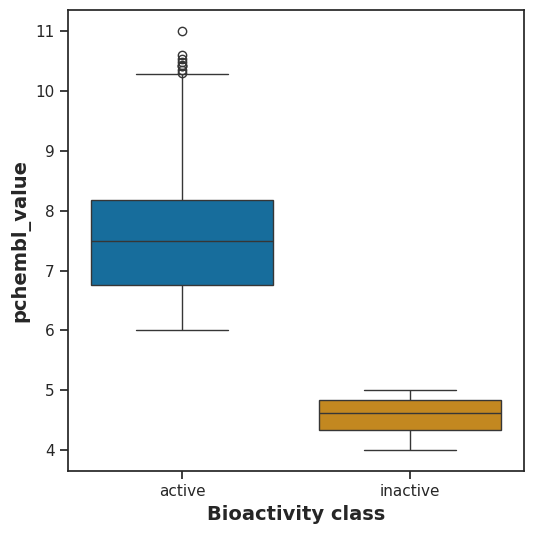

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_pchembl_value.pdf


In [33]:
plot_boxplot_by_class("pchembl_value")

MW

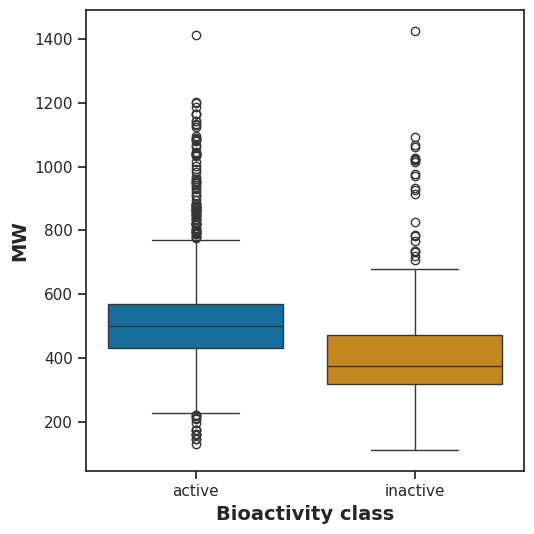

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_MW.pdf


In [36]:
plot_boxplot_by_class("MW")

LogP

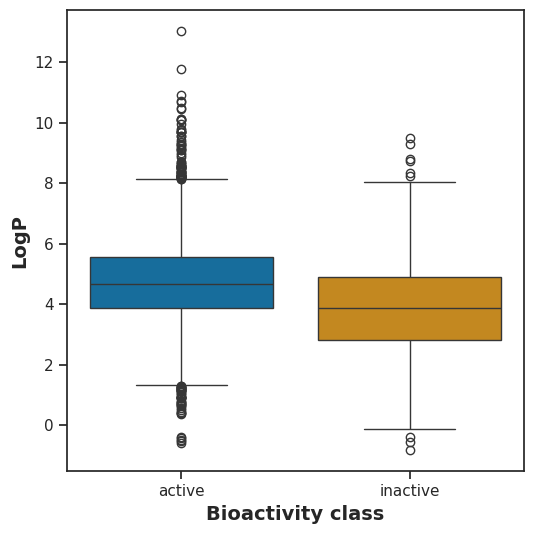

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_LogP.pdf


In [37]:
plot_boxplot_by_class("LogP")

NumHDonors

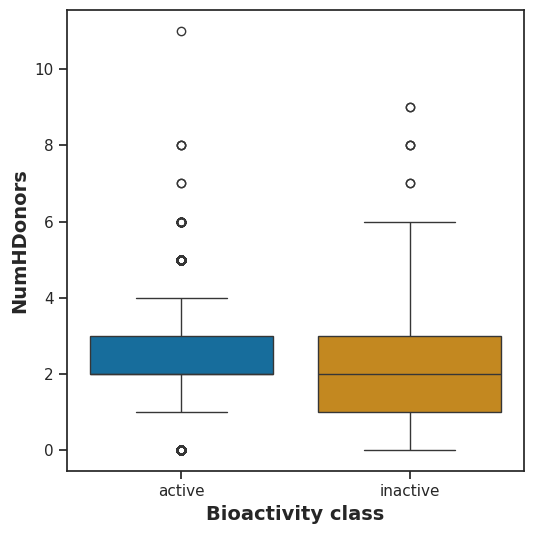

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_NumHDonors.pdf


In [38]:
plot_boxplot_by_class("NumHDonors")

NumHAcceptors

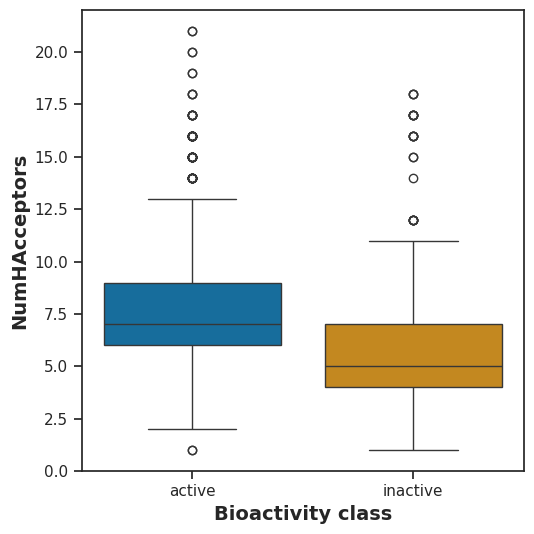

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_NumHAcceptors.pdf


In [39]:
plot_boxplot_by_class("NumHAcceptors")

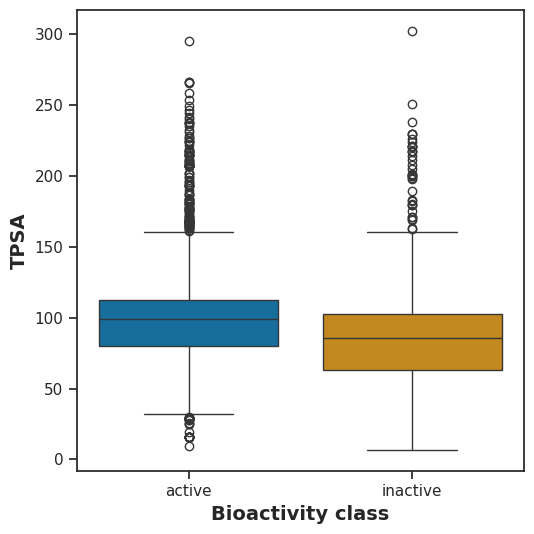

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_TPSA.pdf


In [40]:
plot_boxplot_by_class("TPSA")

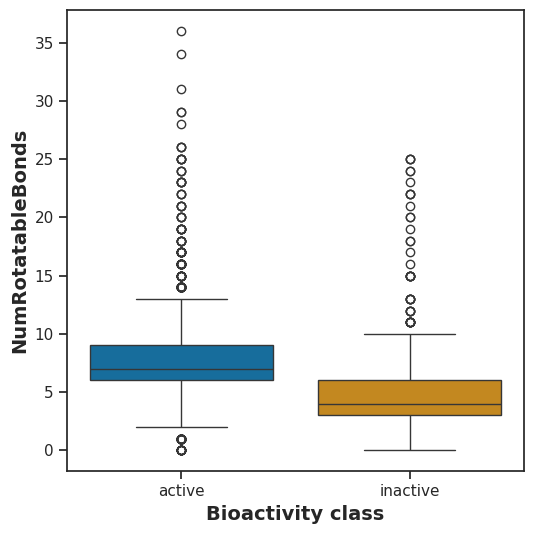

Boxplot guardado en: /workspaces/Drug_discovery/figs/plot_NumRotatableBonds.pdf


In [41]:
plot_boxplot_by_class("NumRotatableBonds")

Interpretation of Statistical Results

Box Plots

**pIC50 values**

Taking a look at pIC50 values, the actives and inactives displayed 

*statistically significant difference*, which is to be expected since threshold
 values (IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives, 
 corresponding to pIC50 > 6 = Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.


**Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited *statistically significant
 difference* between the actives and inactives.